# NewsBot Intelligence System 2.0 — 03 Topic Modeling

## Goal
Discover topics with LDA and NMF, compare diagnostics, and inspect historical topic movement.

This notebook imports reusable project modules rather than duplicating implementation logic.

## Train LDA and NMF
Both models use the same corpus and fixed random state; topic labels require human interpretation.

In [1]:
from src.analysis.topic_modeler import TopicDiscoveryEngine
from src.data_processing.data_validator import load_news_dataset
df = load_news_dataset()
topics = TopicDiscoveryEngine(n_topics=8).fit_topics(df.full_text, df.date)
topics.compare_models()

[{'model': 'lda',
  'topic_diversity': 0.59375,
  'coherence_proxy': 0.8631314310621274,
  'interpretation': 'Compare top-word distinctiveness; validate qualitative meaning in the notebook.'},
 {'model': 'nmf',
  'topic_diversity': 0.96875,
  'coherence_proxy': 0.9953416149068323,
  'interpretation': 'Compare top-word distinctiveness; validate qualitative meaning in the notebook.'}]

## Inspect topic words
Top words are evidence of lexical themes, not authoritative human labels.

In [2]:
{'lda_topic_0': topics.get_topic_words(0, model='lda'), 'nmf_topic_0': topics.get_topic_words(0, model='nmf')}

{'lda_topic_0': [{'word': 'new', 'weight': 31.50651980265439},
  {'word': 'apple', 'weight': 31.006115473342405},
  {'word': 'week', 'weight': 14.03524821172465},
  {'word': 'way', 'weight': 13.347989877837124},
  {'word': 'stress', 'weight': 13.06030191798515},
  {'word': 'iphone', 'weight': 12.785453448627589},
  {'word': 'day', 'weight': 12.604294323854116},
  {'word': 'like', 'weight': 12.481395476103508},
  {'word': 'life', 'weight': 11.839522176117859},
  {'word': 'going', 'weight': 11.719849093106092}],
 'nmf_topic_0': [{'word': 'youtube videos', 'weight': 0.8912624156292931},
  {'word': 'videos week', 'weight': 0.8912624156292931},
  {'word': 'videos', 'weight': 0.8649384783073374},
  {'word': 'youtube', 'weight': 0.8622184893588966},
  {'word': 'week', 'weight': 0.7727682658917198},
  {'word': 'week look', 'weight': 0.44563120781464655},
  {'word': 'week looking', 'weight': 0.44563120781464655},
  {'word': 'looking popular', 'weight': 0.44563120781464655},
  {'word': 'look bri

## Topic evolution
Annual trends describe this local historical sample; they are not live trends.

In [3]:
trends = topics.track_topic_trends()
{'emerging': trends['emerging_topics'], 'declining': trends['declining_topics'], 'spikes': trends['spikes']}

{'emerging': ['topic_2', 'topic_3', 'topic_5'],
 'declining': ['topic_1', 'topic_4', 'topic_0'],
 'spikes': {'topic_0': '2012',
  'topic_1': '2014',
  'topic_2': '2020',
  'topic_3': '2022',
  'topic_4': '2013',
  'topic_5': '2018',
  'topic_6': '2020',
  'topic_7': '2012'}}

## Visual evidence
The reported coherence value is a lexical-overlap proxy and must be read with qualitative review.

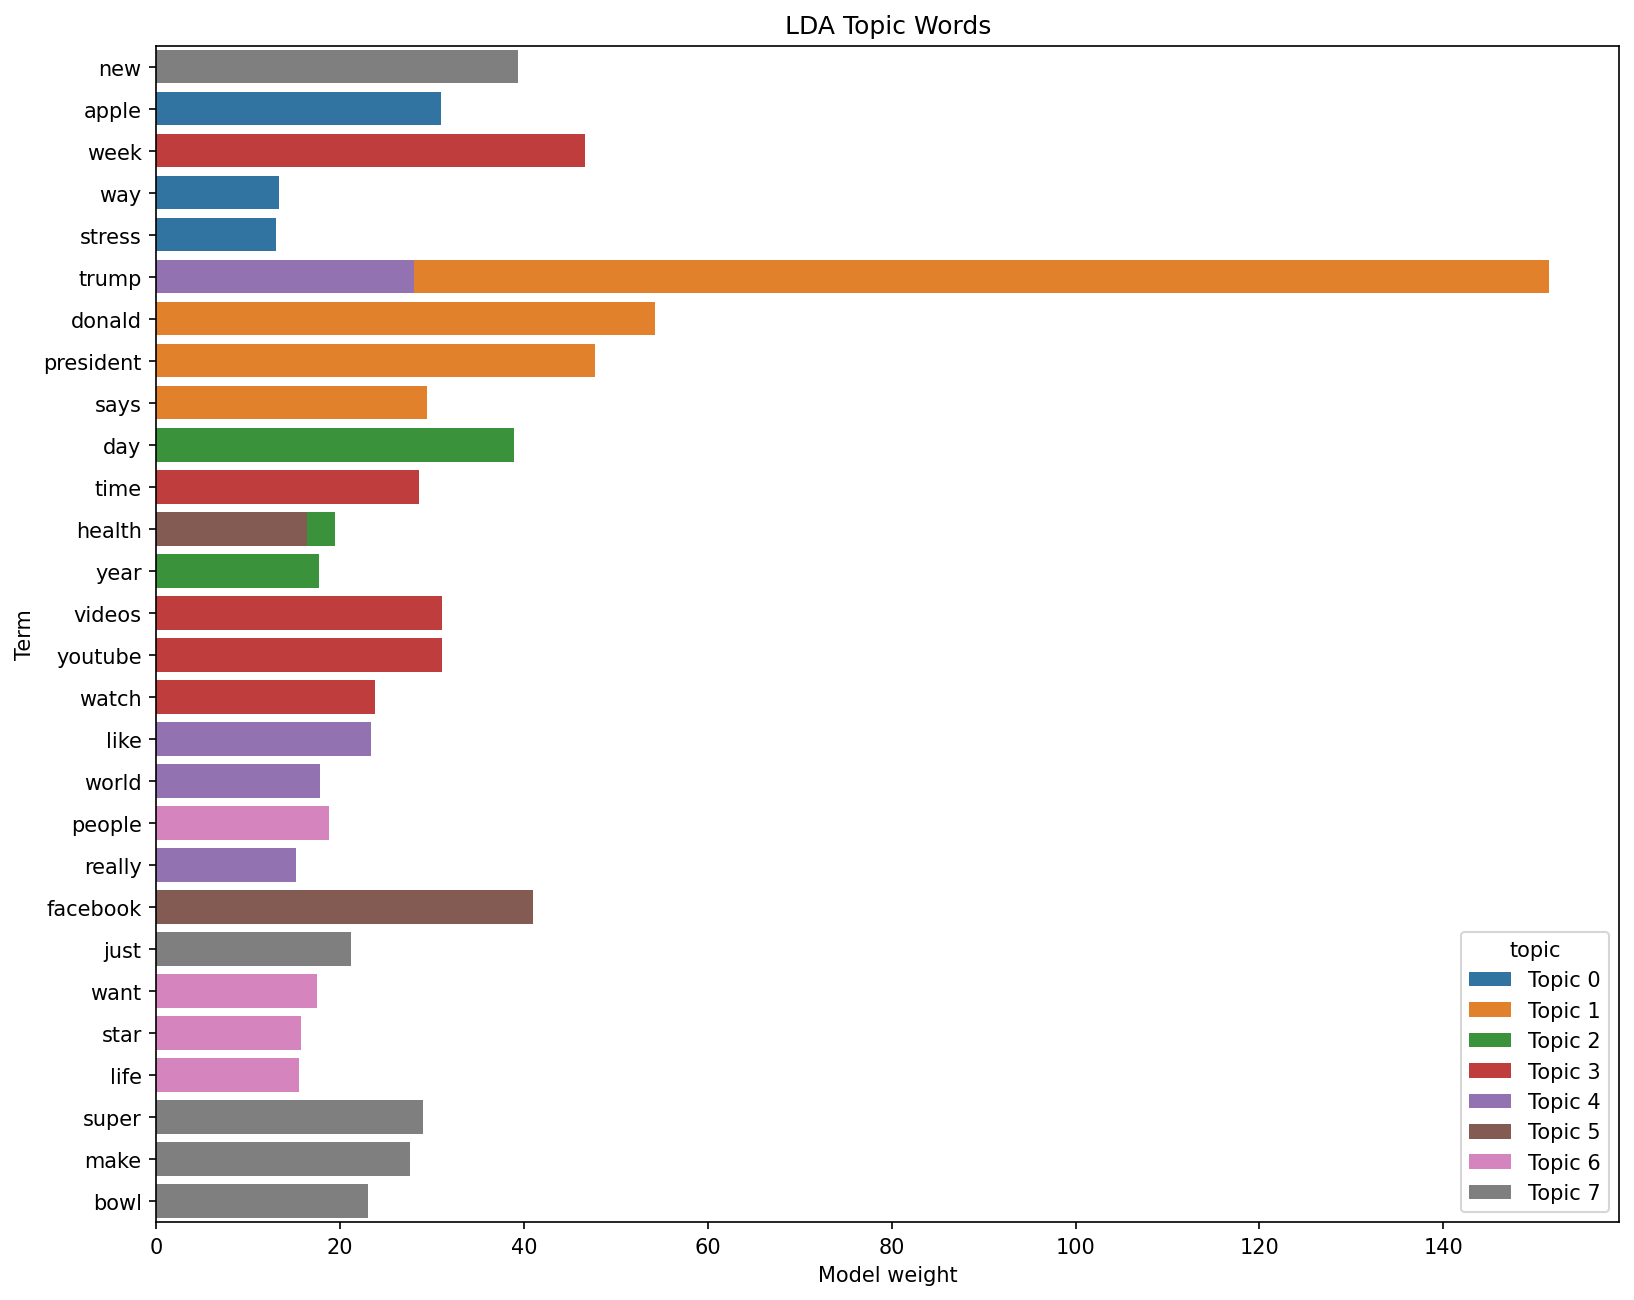

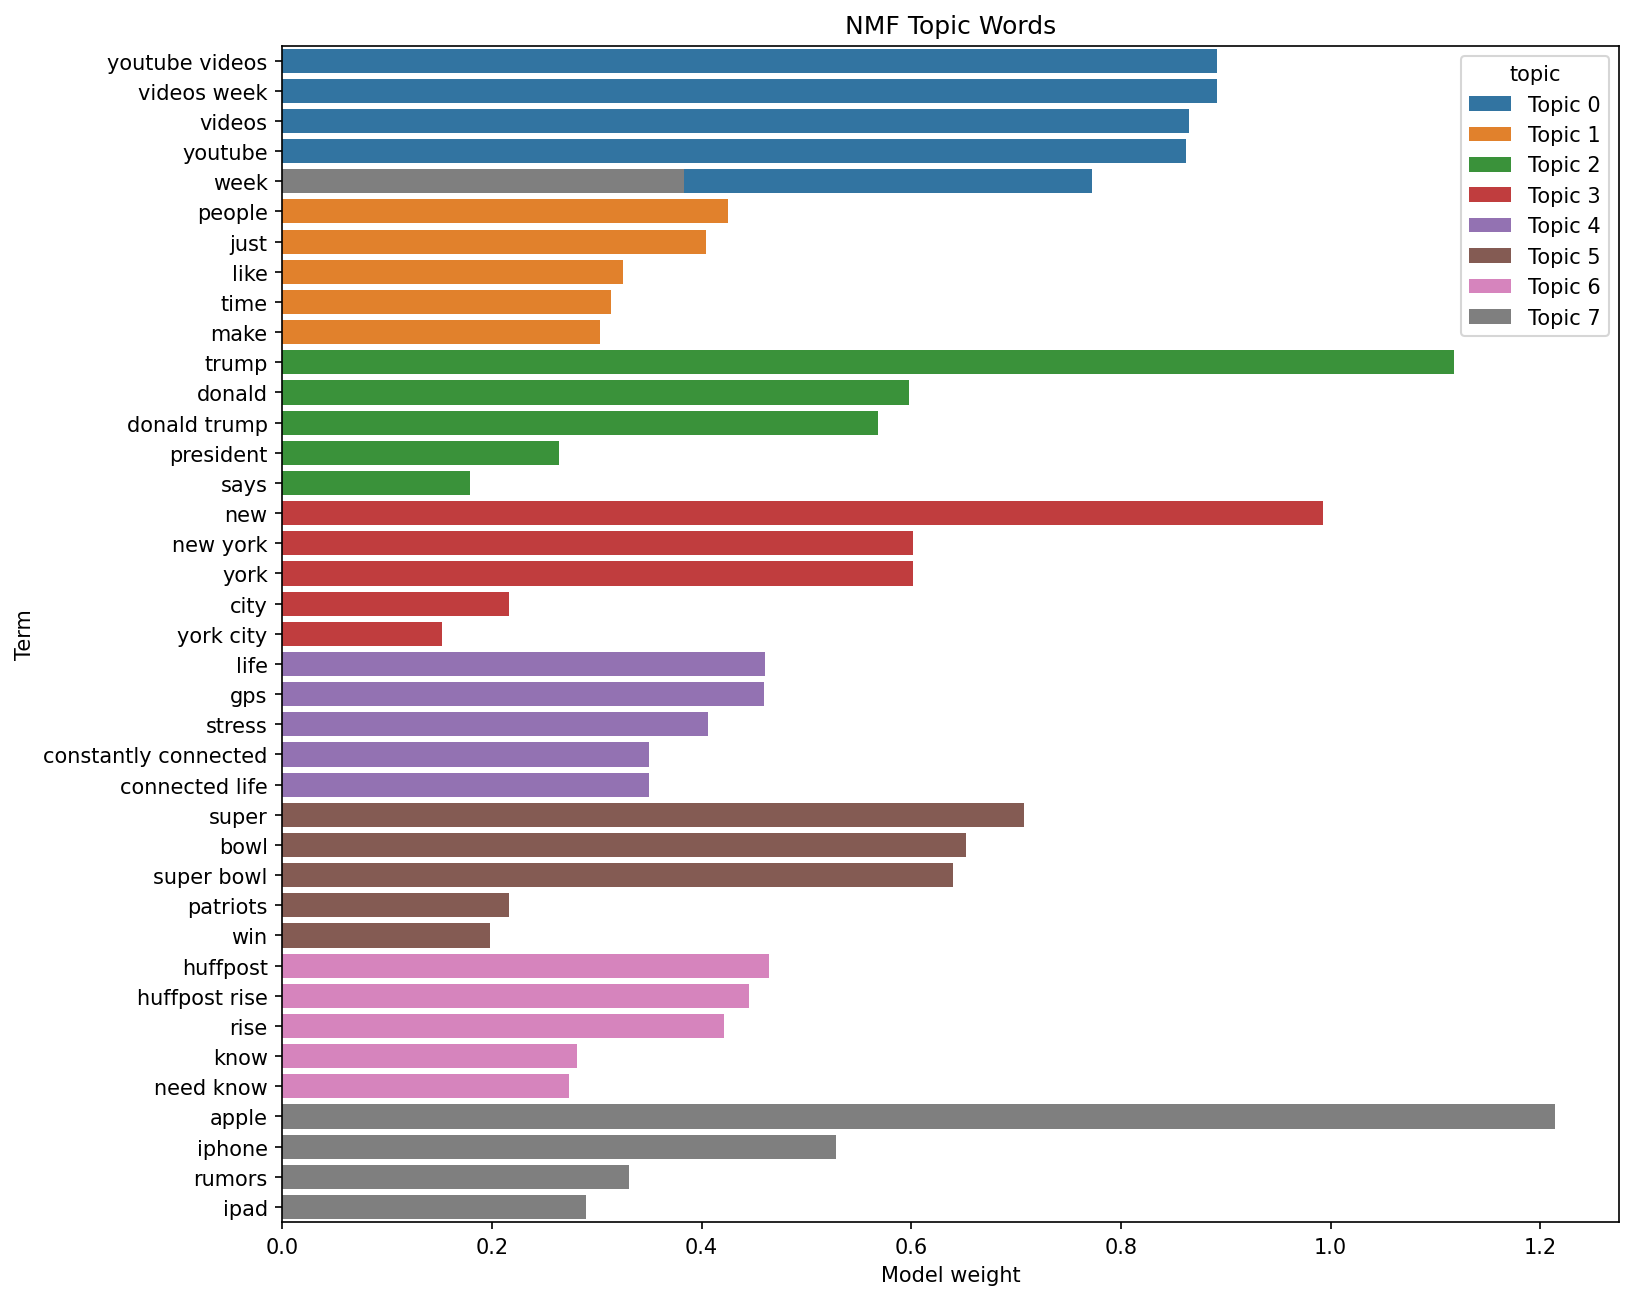

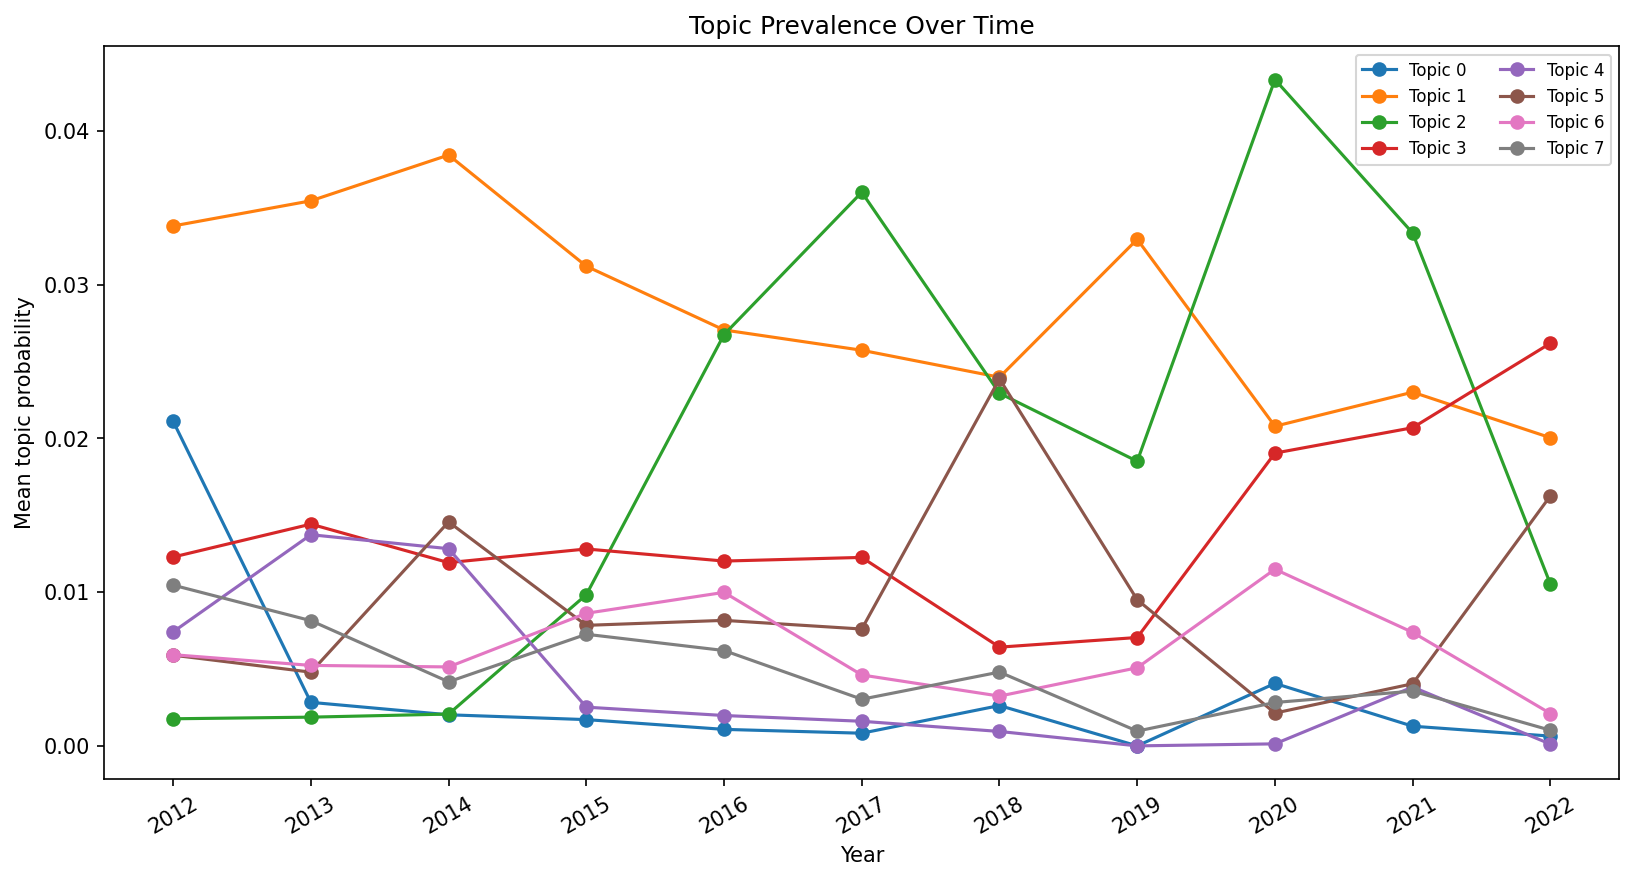

In [4]:
from IPython.display import Image, display
from pathlib import Path
figures = Path('data/results/figures')
for name in ['topic_words_lda.png','topic_words_nmf.png','topic_evolution.png']:
    display(Image(filename=str(figures / name)))

## Limitations and ethics
The source corpus is historical and predominantly English. Confidence is not truth; sentiment, topics, named entities, translation, summaries, and semantic similarity can be wrong. Entity co-occurrence is not a proven real-world relationship. Internal corpus corroboration is not independent fact-checking.